In [39]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [40]:
from google.colab import files
uploaded = files.upload()
print("File terupload:", list(uploaded.keys()))

Saving Zakaria_Excel (1).xlsx to Zakaria_Excel (1) (2).xlsx
File terupload: ['Zakaria_Excel (1) (2).xlsx']


In [41]:
import glob

# Mencari file Excel yang sudah diupload secara otomatis
daftar_excel = glob.glob("*Zakaria_Excel (1).xlsx")
print("File Excel ditemukan:", daftar_excel)
FILE_EXCEL = daftar_excel[0]

# Folder untuk menyimpan hasil
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)

# Tema dan warna grafik
WARNA = ["#1b4965", "#5fa8d3", "#62b6cb", "#bee9e8", "#cae9ff", "#e76f51"]
sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

File Excel ditemukan: ['Zakaria_Excel (1).xlsx']


In [42]:
df = pd.read_excel(FILE_EXCEL, header=None, skiprows=7, usecols="B:F", nrows=31)
df.columns = ["ID", "Nama", "Quiz", "UTS", "UAS"]

print("Jumlah baris & kolom:", df.shape)
print("Missing value:", df.isna().sum().sum())
df.head()

Jumlah baris & kolom: (31, 5)
Missing value: 0


,ID,Nama,Quiz,UTS,UAS
0,2455301205,Zakaria Hutabarat,78,85,93
1,120003,John Doe,85,78,90
2,120005,Jane Smith,92,88,94
3,120017,Michael Johnson,48,65,56
4,120018,Emily Brown,90,85,88


In [43]:
df["Nilai_Akhir"] = (df["Quiz"]*0.32 + df["UTS"]*0.33 + df["UAS"]*0.35).round(2)

def tentukan_grade(x):
    if x >= 81: return "A"
    if x >= 76: return "AB"
    if x >= 66: return "B"
    if x >= 61: return "BC"
    if x >= 51: return "C"
    return "F"

df["Grade"] = df["Nilai_Akhir"].apply(tentukan_grade)
df

,ID,Nama,Quiz,UTS,UAS,Nilai_Akhir,Grade
0,2455301205,Zakaria Hutabarat,78,85,93,85.56,A
1,120003,John Doe,85,78,90,84.44,A
2,120005,Jane Smith,92,88,94,91.38,A
3,120017,Michael Johnson,48,65,56,56.41,C
4,120018,Emily Brown,90,85,88,87.65,A
5,120022,Daniel Martinez,75,80,77,77.35,AB
6,120024,Sarah Wilson,88,70,65,74.01,B
7,120025,David Garcia,75,70,75,73.35,B
8,120027,Jessica Lee,95,91,96,94.03,A
9,120034,Matthew Davis,79,84,78,80.30,AB


In [44]:
x = df["Nilai_Akhir"]

deskriptif = pd.DataFrame({
    "Statistik": ["Mean", "Standard Error", "Median", "Mode", "Standard Deviation",
                  "Sample Variance", "Kurtosis", "Skewness", "Range", "Minimum",
                  "Maximum", "Q1 (25%)", "Q3 (75%)", "IQR", "Sum", "Count"],
    "Nilai": [x.mean(), x.sem(), x.median(), x[x.isin(x.mode())].iloc[0], x.std(),
              x.var(), x.kurt(), x.skew(), x.max()-x.min(), x.min(),
              x.max(), x.quantile(.25), x.quantile(.75),
              x.quantile(.75)-x.quantile(.25), x.sum(), x.count()],
}).round(4)
deskriptif

,Statistik,Nilai
0,Mean,76.5226
1,Standard Error,2.3970
2,Median,79.3000
3,Mode,80.3000
4,Standard Deviation,13.3461
5,Sample Variance,178.1172
6,Kurtosis,-0.4488
7,Skewness,-0.7183
8,Range,48.0200
9,Minimum,46.0100


In [45]:
komponen = df[["Quiz","UTS","UAS","Nilai_Akhir"]].agg(
    ["count","mean","median","std","min","max"]).T.round(2)
print(komponen)

korelasi = df[["Quiz","UTS","UAS","Nilai_Akhir"]].corr().round(3)
print(korelasi)

             count   mean  median    std    min    max
Quiz          31.0  76.16    78.0  14.70  41.00  95.00
UTS           31.0  77.29    82.0  13.54  48.00  95.00
UAS           31.0  76.13    77.0  13.92  44.00  96.00
Nilai_Akhir   31.0  76.52    79.3  13.35  46.01  94.03
              Quiz    UTS    UAS  Nilai_Akhir
Quiz         1.000  0.834  0.856        0.944
UTS          0.834  1.000  0.874        0.947
UAS          0.856  0.874  1.000        0.959
Nilai_Akhir  0.944  0.947  0.959        1.000


In [46]:
sw_stat, sw_p = stats.shapiro(x)
print(f"W = {sw_stat:.4f}, p-value = {sw_p:.4f}")
print("Kesimpulan:", "berdistribusi normal" if sw_p > 0.05 else "tidak berdistribusi normal")

W = 0.9242, p-value = 0.0305
Kesimpulan: tidak berdistribusi normal


In [47]:
urutan = ["A", "AB", "B", "BC", "C", "F"]
rentang = {"A":">= 81","AB":">= 76","B":">= 66","BC":">= 61","C":">= 51","F":">= 0"}
frek = df["Grade"].value_counts().reindex(urutan, fill_value=0)

tabel_grade = pd.DataFrame({
    "Score": [rentang[g] for g in urutan],
    "Grade": urutan,
    "Frequency": frek.values,
    "Percentage (%)": (frek.values / len(df) * 100).round(2),
})
tabel_grade

,Score,Grade,Frequency,Percentage (%)
0,>= 81,A,13,41.94
1,>= 76,AB,7,22.58
2,>= 66,B,4,12.90
3,>= 61,BC,1,3.23
4,>= 51,C,5,16.13
5,>= 0,F,1,3.23


In [48]:
k = int(np.ceil(1 + 3.322*np.log10(len(x))))
lebar = np.ceil((x.max() - x.min()) / k)
batas = np.arange(np.floor(x.min()), x.max() + lebar, lebar)

kelas = pd.cut(x, bins=batas, right=False)
frek_kelas = kelas.value_counts().sort_index()

tabel_kelas = pd.DataFrame({
    "Kelas Interval": frek_kelas.index.astype(str),
    "Frekuensi": frek_kelas.values,
})
tabel_kelas["Relatif (%)"] = (tabel_kelas["Frekuensi"]/len(x)*100).round(2)
tabel_kelas["Kumulatif"] = tabel_kelas["Frekuensi"].cumsum()
tabel_kelas

,Kelas Interval,Frekuensi,Relatif (%),Kumulatif
0,"[46.0, 55.0)",2,6.45,2
1,"[55.0, 64.0)",5,16.13,7
2,"[64.0, 73.0)",2,6.45,9
3,"[73.0, 82.0)",10,32.26,19
4,"[82.0, 91.0)",7,22.58,26
5,"[91.0, 100.0)",5,16.13,31


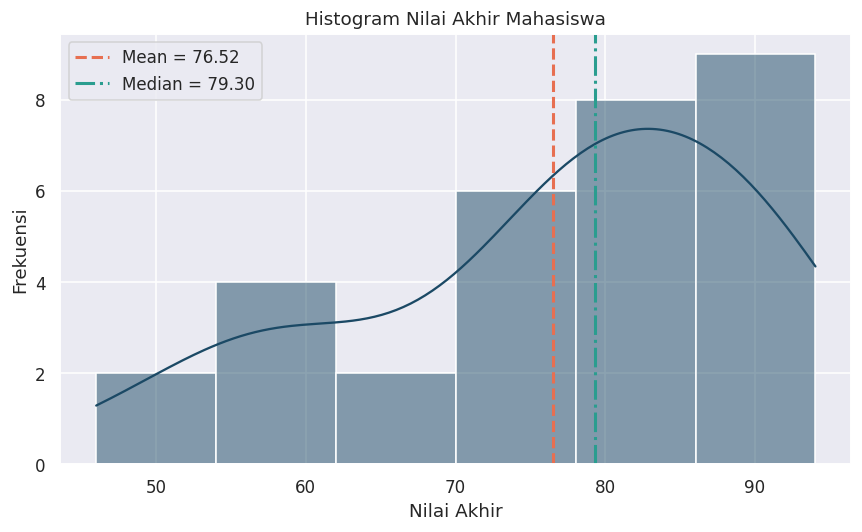

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(x, bins=k, kde=True, color=WARNA[0], edgecolor="white", ax=ax)
ax.axvline(x.mean(), color="#e76f51", ls="--", lw=2, label=f"Mean = {x.mean():.2f}")
ax.axvline(x.median(), color="#2a9d8f", ls="-.", lw=2, label=f"Median = {x.median():.2f}")
ax.set_title("Histogram Nilai Akhir Mahasiswa")
ax.set_xlabel("Nilai Akhir"); ax.set_ylabel("Frekuensi"); ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_histogram.png", dpi=150)
plt.show()

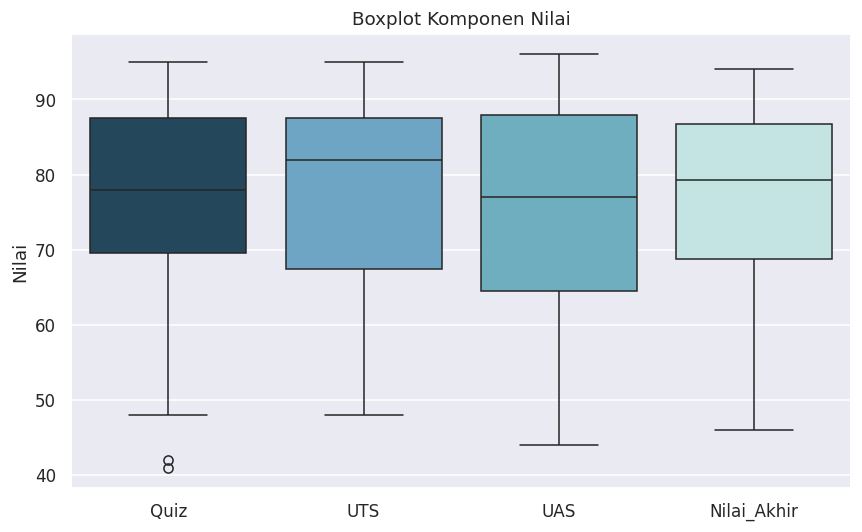

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df[["Quiz","UTS","UAS","Nilai_Akhir"]], palette=WARNA[:4], ax=ax)
ax.set_title("Boxplot Komponen Nilai"); ax.set_ylabel("Nilai")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_boxplot.png", dpi=150)
plt.show()

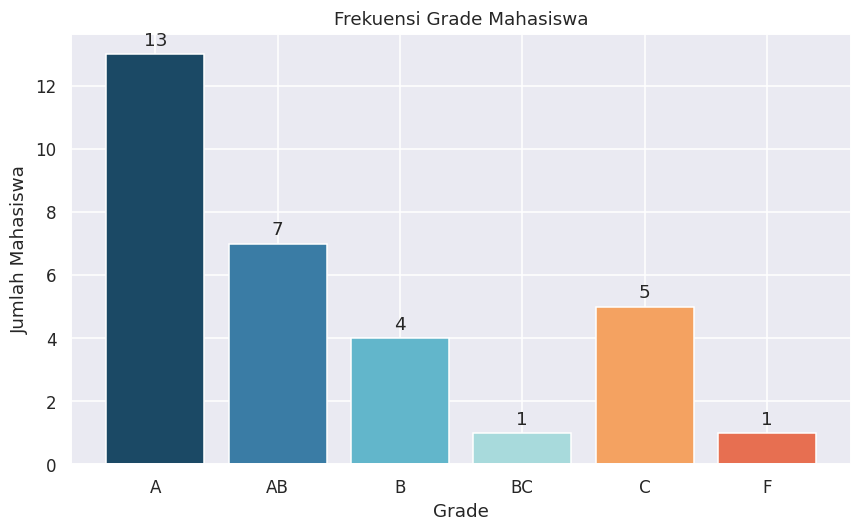

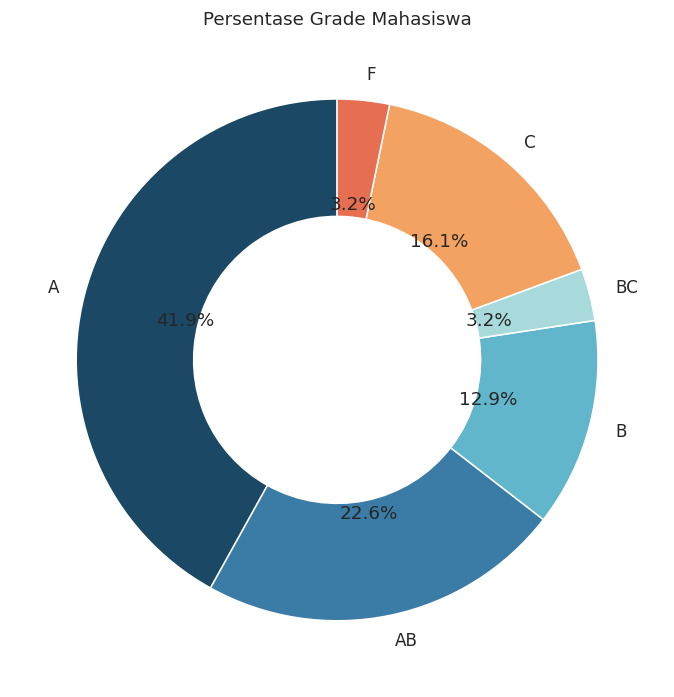

In [51]:
warna_grade = ["#1b4965","#3a7ca5","#62b6cb","#a8dadc","#f4a261","#e76f51"]

# Diagram batang
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(urutan, frek.values, color=warna_grade, edgecolor="white")
ax.bar_label(bars, padding=3)
ax.set_title("Frekuensi Grade Mahasiswa")
ax.set_xlabel("Grade"); ax.set_ylabel("Jumlah Mahasiswa")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_bar_grade.png", dpi=150)
plt.show()

# Diagram donut
fig, ax = plt.subplots(figsize=(6.5, 6.5))
nz = frek[frek > 0]
ax.pie(nz.values, labels=nz.index, autopct="%1.1f%%", startangle=90,
       colors=[warna_grade[urutan.index(g)] for g in nz.index],
       wedgeprops=dict(width=0.45, edgecolor="white"))
ax.set_title("Persentase Grade Mahasiswa")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_pie_grade.png", dpi=150)
plt.show()

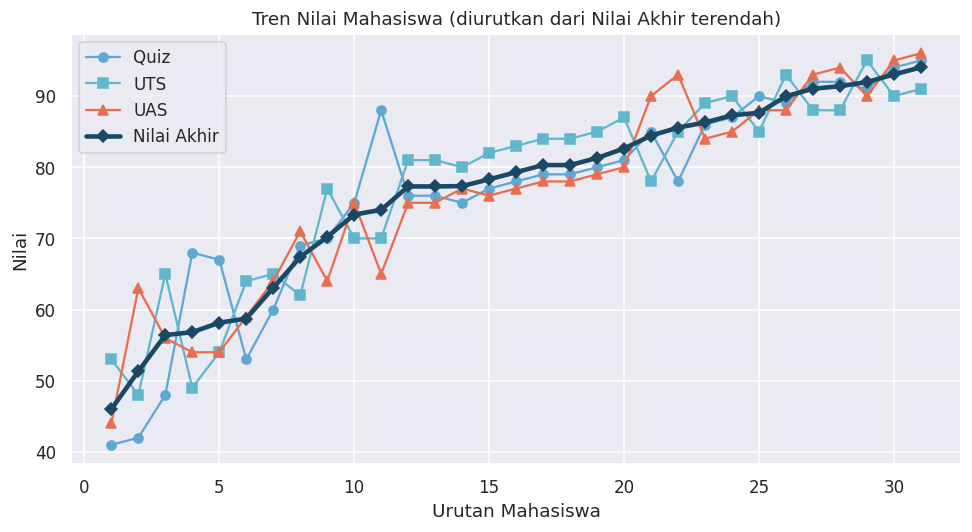

In [52]:
urut = df.sort_values("Nilai_Akhir").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(urut.index+1, urut["Quiz"], marker="o", label="Quiz", color=WARNA[1])
ax.plot(urut.index+1, urut["UTS"], marker="s", label="UTS", color=WARNA[2])
ax.plot(urut.index+1, urut["UAS"], marker="^", label="UAS", color=WARNA[5])
ax.plot(urut.index+1, urut["Nilai_Akhir"], marker="D", lw=3, label="Nilai Akhir", color=WARNA[0])
ax.set_title("Tren Nilai Mahasiswa (diurutkan dari Nilai Akhir terendah)")
ax.set_xlabel("Urutan Mahasiswa"); ax.set_ylabel("Nilai"); ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_line_nilai.png", dpi=150)
plt.show()

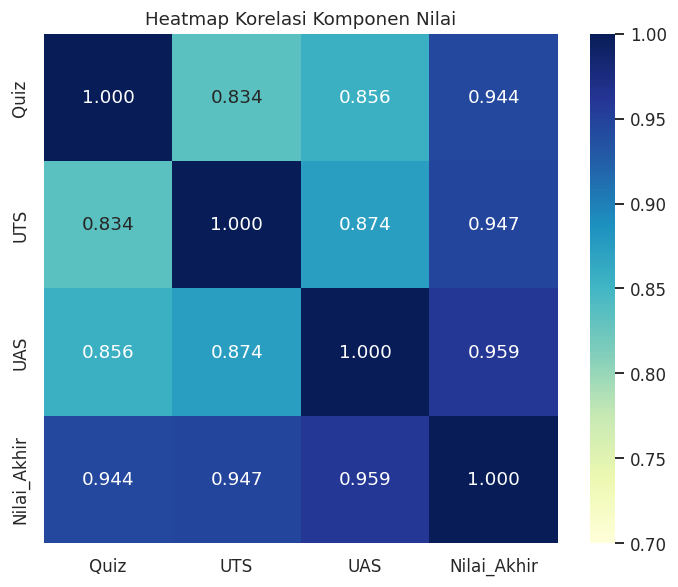

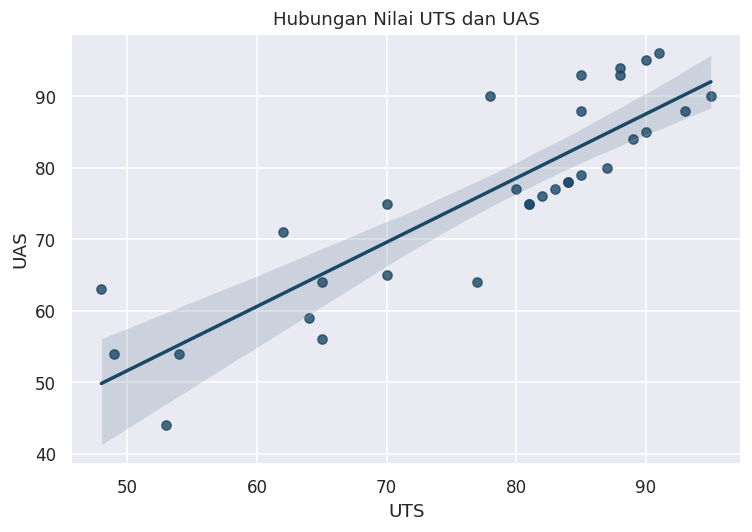

In [53]:
# Heatmap korelasi
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(korelasi, annot=True, cmap="YlGnBu", vmin=0.7, vmax=1, fmt=".3f", ax=ax)
ax.set_title("Heatmap Korelasi Komponen Nilai")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_heatmap.png", dpi=150)
plt.show()

# Scatter plot UTS vs UAS
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x="UTS", y="UAS", data=df, color=WARNA[0], ax=ax)
ax.set_title("Hubungan Nilai UTS dan UAS")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/07_scatter.png", dpi=150)
plt.show()

In [54]:
import shutil
from google.colab import files

excel_out = f"{OUT_DIR}/Hasil_Python_Zakaria.xlsx"

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Data Nilai", index=False)
    deskriptif.to_excel(writer, sheet_name="Statistika Deskriptif", index=False)
    tabel_grade.to_excel(writer, sheet_name="Frekuensi Grade", index=False)
    tabel_kelas.to_excel(writer, sheet_name="Distribusi Frekuensi", index=False)
    komponen.to_excel(writer, sheet_name="Komponen Nilai")
    korelasi.to_excel(writer, sheet_name="Korelasi")

    for ws in writer.book.worksheets:
        for col in ws.columns:
            lebar_kol = max(len(str(c.value)) if c.value is not None else 0 for c in col)
            ws.column_dimensions[col[0].column_letter].width = min(lebar_kol + 4, 40)

# Kompres folder output menjadi satu file ZIP lalu download
shutil.make_archive("hasil_pertemuan4", "zip", OUT_DIR)
files.download("hasil_pertemuan4.zip")
print("Selesai! Semua hasil sudah di-download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Selesai! Semua hasil sudah di-download.
